#MARKDOWN
# Workforce360 — Exploratory Data Analysis

This notebook explores the IBM HR Employee Attrition dataset after Workforce360 preprocessing.

## Objectives

- Understand workforce demographics and composition.
- Analyze attrition patterns.
- Examine associations between attrition, overtime, satisfaction, tenure, compensation, and department.
- Identify early insights that will guide dashboard and machine-learning development.

> **Ethics note:** This is a portfolio/learning dataset. Results are descriptive and should not be used for automated employment decisions.

In [1]:
#CELL 2
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.load import load_raw_ibm_hr
from src.data.preprocess import clean_hr_data, save_processed_data

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)

In [2]:
#CELL 3
raw_df = load_raw_ibm_hr()
df = clean_hr_data(raw_df)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Total missing values: {df.isna().sum().sum()}")

df.head()

Rows: 1470
Columns: 43
Duplicate rows: 0
Total missing values: 0


,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,source_employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,overtime,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion_source,years_with_curr_manager,employee_id,attrition_flag,overtime_flag,age_group,tenure_bucket,years_since_promotion,income_vs_department_avg,is_below_department_income_avg
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,EMP0001,1,1,36-45,6-10 years,0,0.861,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,EMP0002,0,0,46-55,6-10 years,1,0.817,1
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,EMP0004,1,1,36-45,0-1 years,0,0.333,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,EMP0005,0,1,26-35,6-10 years,3,0.463,1
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,EMP0007,0,0,26-35,2-3 years,2,0.552,1


In [3]:
#CELL 4
df.info()

df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   age                                1470 non-null   int64   
 1   attrition                          1470 non-null   str     
 2   business_travel                    1470 non-null   str     
 3   daily_rate                         1470 non-null   int64   
 4   department                         1470 non-null   str     
 5   distance_from_home                 1470 non-null   int64   
 6   education                          1470 non-null   int64   
 7   education_field                    1470 non-null   str     
 8   employee_count                     1470 non-null   int64   
 9   source_employee_number             1470 non-null   int64   
 10  environment_satisfaction           1470 non-null   int64   
 11  gender                             1470 non-null   str

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_travel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_rate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_from_home,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
education_field,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_count,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
source_employee_number,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [4]:
#CELL 5
attrition_summary = (
    df["attrition"]
    .value_counts()
    .rename_axis("attrition")
    .reset_index(name="employees")
)

attrition_summary["percentage"] = (
    attrition_summary["employees"] / attrition_summary["employees"].sum() * 100
).round(2)

attrition_summary

,attrition,employees,percentage
0,No,1233,83.88
1,Yes,237,16.12


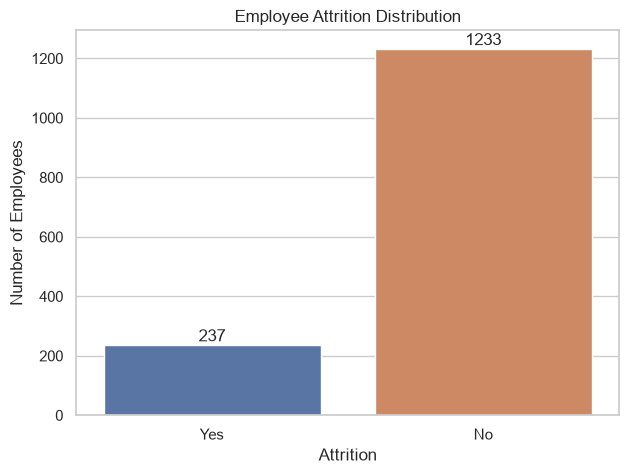

In [5]:
#CELL 6
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="attrition",
    hue="attrition",
    legend=False,
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

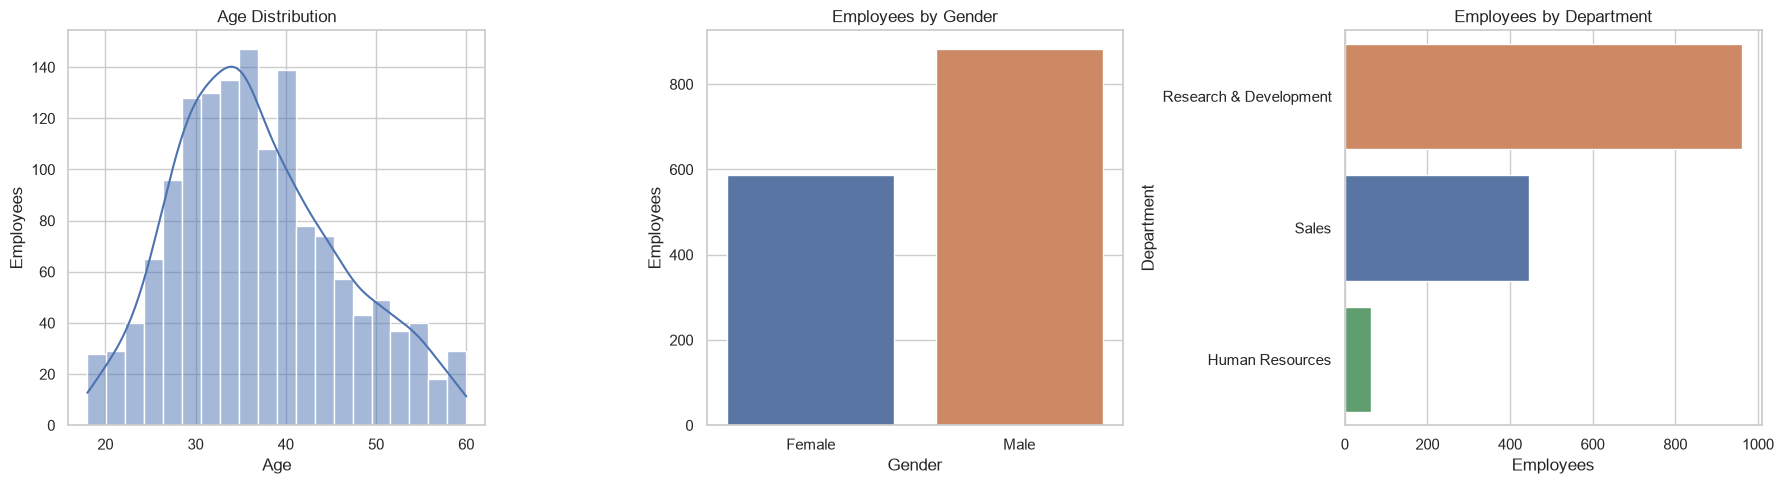

In [6]:
#CELL 7
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Employees")

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Employees by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Employees")

department_order = df["department"].value_counts().index

sns.countplot(
    data=df,
    y="department",
    order=department_order,
    hue="department",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Employees by Department")
axes[2].set_xlabel("Employees")
axes[2].set_ylabel("Department")

plt.tight_layout()
plt.show()

In [7]:
#CELL 8
department_attrition = (
    df.groupby("department", observed=False)["attrition_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="attrition_rate")
)

job_role_attrition = (
    df.groupby("job_role", observed=False)["attrition_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="attrition_rate")
)

display(department_attrition)
display(job_role_attrition)

,department,attrition_rate
0,Sales,20.627803
1,Human Resources,19.047619
2,Research & Development,13.839750


,job_role,attrition_rate
0,Sales Representative,39.759036
1,Laboratory Technician,23.938224
2,Human Resources,23.076923
3,Sales Executive,17.484663
4,Research Scientist,16.095890
5,Manufacturing Director,6.896552
6,Healthcare Representative,6.870229
7,Manager,4.901961
8,Research Director,2.500000


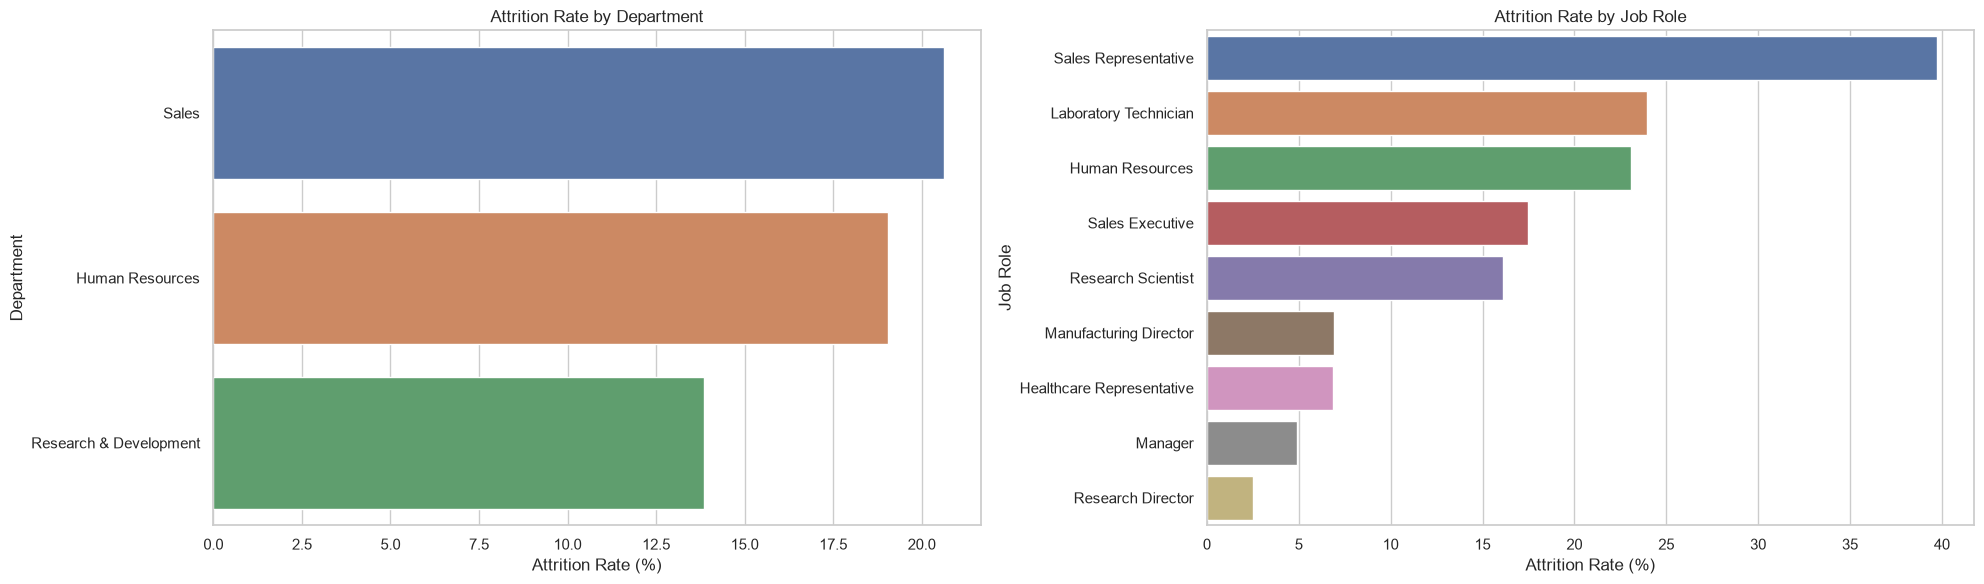

In [8]:
#CELL 9
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(
    data=department_attrition,
    x="attrition_rate",
    y="department",
    hue="department",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Attrition Rate (%)")
axes[0].set_ylabel("Department")

sns.barplot(
    data=job_role_attrition,
    x="attrition_rate",
    y="job_role",
    hue="job_role",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Attrition Rate (%)")
axes[1].set_ylabel("Job Role")

plt.tight_layout()
plt.show()

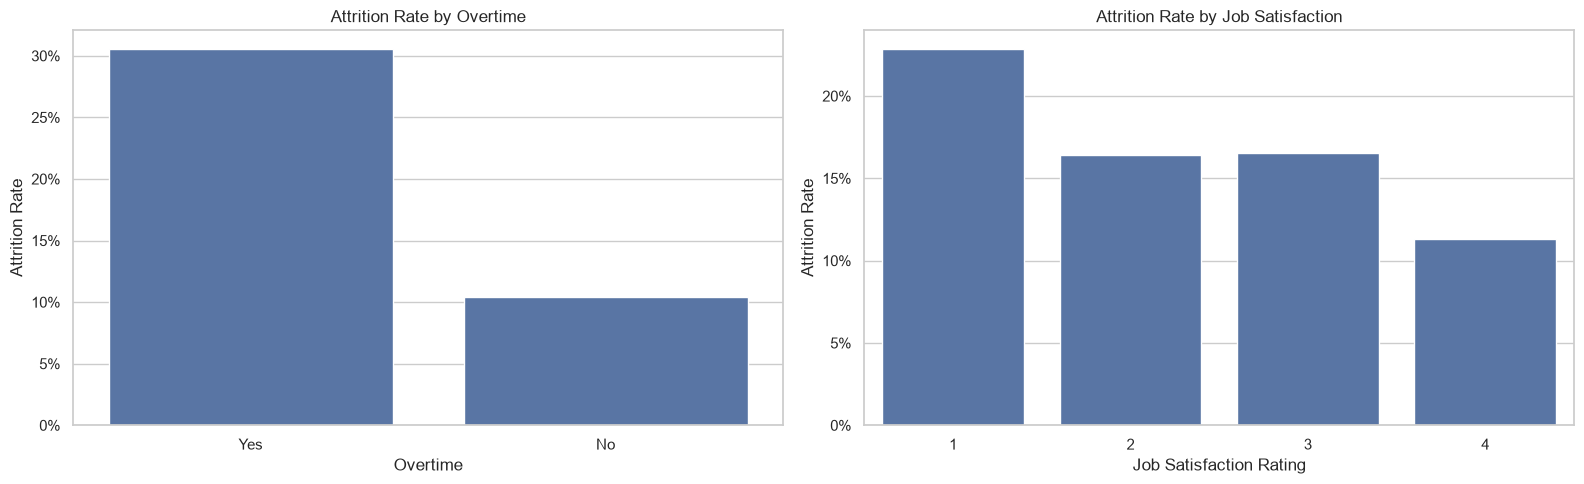

In [9]:
#CELL 10
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=df,
    x="overtime",
    y="attrition_flag",
    estimator="mean",
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Attrition Rate by Overtime")
axes[0].set_xlabel("Overtime")
axes[0].set_ylabel("Attrition Rate")
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

sns.barplot(
    data=df,
    x="job_satisfaction",
    y="attrition_flag",
    estimator="mean",
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Attrition Rate by Job Satisfaction")
axes[1].set_xlabel("Job Satisfaction Rating")
axes[1].set_ylabel("Attrition Rate")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

plt.tight_layout()
plt.show()

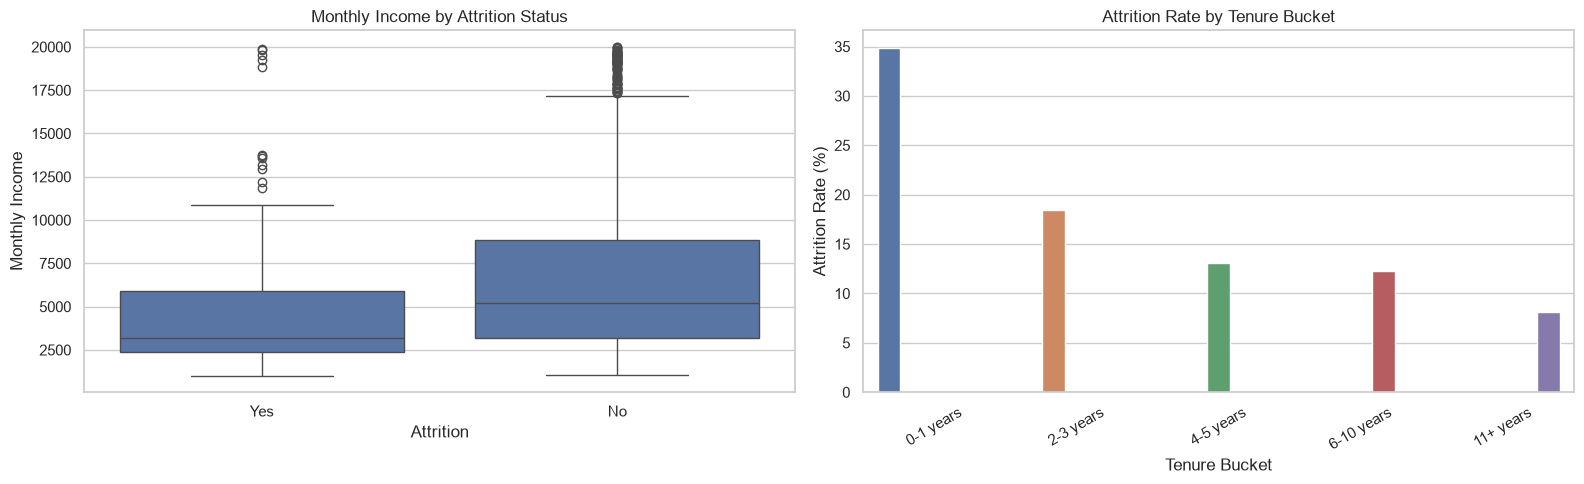

In [10]:
#CELL 11
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=df,
    x="attrition",
    y="monthly_income",
    ax=axes[0],
)
axes[0].set_title("Monthly Income by Attrition Status")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Monthly Income")

tenure_attrition = (
    df.groupby("tenure_bucket", observed=False)["attrition_flag"]
    .mean()
    .mul(100)
    .reset_index(name="attrition_rate")
)

sns.barplot(
    data=tenure_attrition,
    x="tenure_bucket",
    y="attrition_rate",
    hue="tenure_bucket",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Attrition Rate by Tenure Bucket")
axes[1].set_xlabel("Tenure Bucket")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

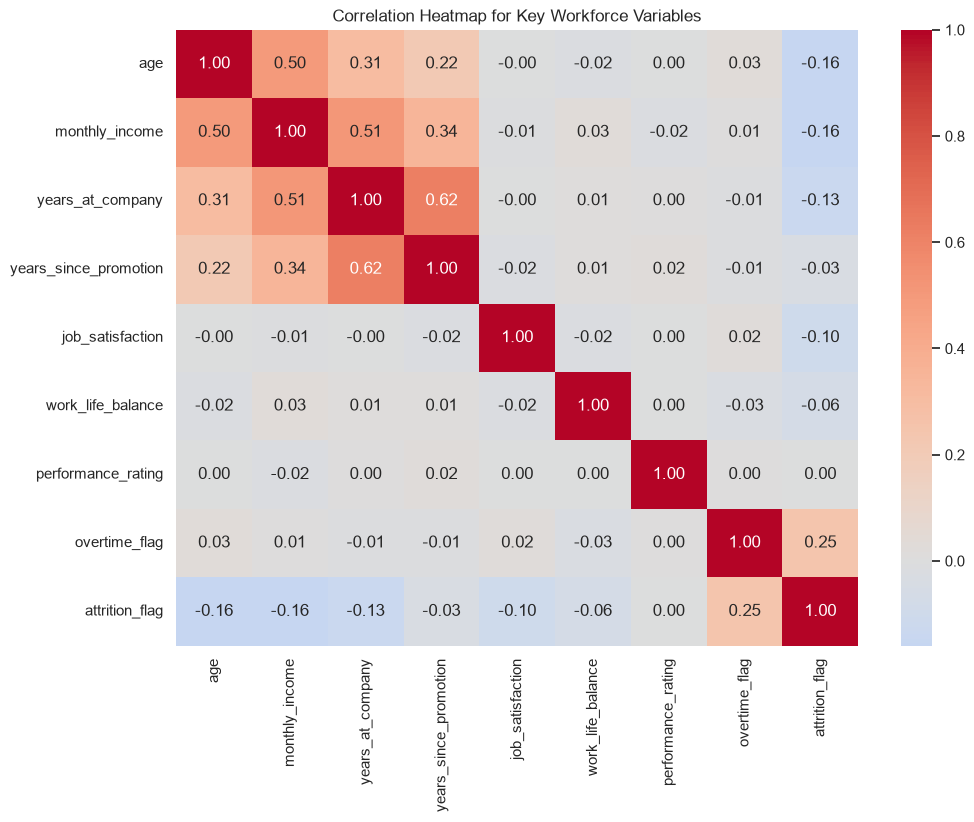

In [11]:
#CELL 12
correlation_columns = [
    "age",
    "monthly_income",
    "years_at_company",
    "years_since_promotion",
    "job_satisfaction",
    "work_life_balance",
    "performance_rating",
    "overtime_flag",
    "attrition_flag",
]

correlation_matrix = df[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)

plt.title("Correlation Heatmap for Key Workforce Variables")
plt.show()

## Initial Insights

Complete this section only after reviewing all outputs.

1. **Overall attrition:** The observed attrition rate is approximately `_____ %`.
2. **Department pattern:** The department with the highest observed attrition rate is `_____`.
3. **Overtime pattern:** Employees working overtime show a `higher/lower` observed attrition rate than employees not working overtime.
4. **Job satisfaction:** Attrition changes across satisfaction levels, so job satisfaction may be a useful future model feature.
5. **Tenure:** Attrition is more concentrated in the `_____` tenure group(s).
6. **Compensation:** Income distributions differ between attrition groups. This is an association and does not prove that compensation caused employee exits.

## Responsible Interpretation

- Correlation and observed group differences do not establish causation.
- Model predictions should support human investigation and judgment, not automate employment decisions.
- This IBM HR data is used for learning and portfolio development, not as real organizational data.

In [21]:
#CELL 14
output_path = save_processed_data(df)

print(f"Processed data saved to: {output_path}")

Processed data saved to: C:\Users\Anvesha Garg\Desktop\workforce360\workforce360\data\processed\employees_clean.csv
